In [4]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

In [5]:
np.random.seed(124)
m = 100 # Number of training examples
x_train = 2 * np.random.rand(m,1)
y_train = 4 + 3 * x_train + np.random.randn(m,1)

In [6]:
theta_0 = np.random.randn() # Bias/Intercept
theta_1 = np.random.randn() # Weight/Slope

learning_rate = 0.1
iterations = 200

In [7]:
def compute_cost(x, y, theta_0, theta_1):
    predictions = theta_0 + theta_1 * x
    cost = (1/(2*m)) * np.sum((predictions - y) ** 2)
    return cost

In [8]:
def grad_desc(x, y, theta_0, theta_1, learning_rate, iterations):
    cost_history_over_time = []

    for i in range(iterations):
        predictions = theta_0 + theta_1 * x

        #Now the gradients
        d_theta_0 = (1/m) * np.sum(predictions - y)
        d_theta_1 = (1/m) * np.sum((predictions - y) * x) 

        theta_0 = theta_0 - (learning_rate * d_theta_0)
        theta_1 = theta_1 - (learning_rate * d_theta_1)

        cost = compute_cost(x, y, theta_0, theta_1)
        cost_history_over_time.append(cost)
    return theta_0, theta_1, cost_history_over_time

In [9]:
theta_0, theta_1, cost_history_over_time = grad_desc(x_train, y_train, theta_0, theta_1, learning_rate, iterations)
print(f"Theta_0 = {theta_0}")
print(f"Theta_1 = {theta_1}")
print(f"Final Cost = {cost_history_over_time[-1:]}")

Theta_0 = 4.188747794317596
Theta_1 = 2.9521620915230953
Final Cost = [np.float64(0.44786164609367296)]


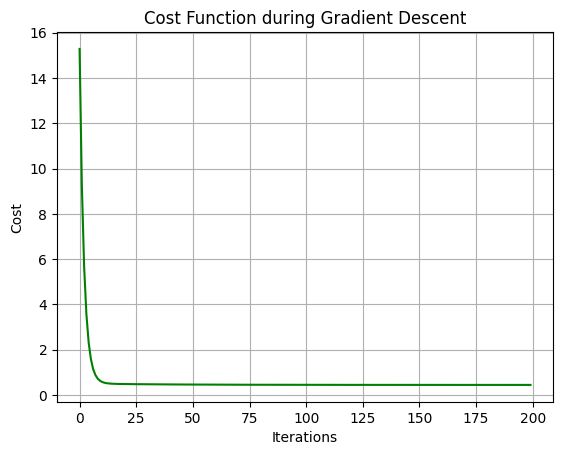

In [10]:
plt.plot(range(iterations), cost_history_over_time, c='g')
plt.title('Cost Function during Gradient Descent')
plt.xlabel('Iterations')
plt.ylabel('Cost')
plt.grid(True)
plt.show()

* `θ₀` is the **intercept** (or bias),
* `θ₁` is the **slope** (or weight),
* `x` is the input feature, and
* `y` is the output or target.

Our objective is to minimize the **cost function** (which is the **Mean Squared Error**, MSE):

$$
J(\theta_0, \theta_1) = \frac{1}{2m} \sum_{i=1}^{m} (h(x^{(i)}) - y^{(i)})^2
$$

Where `h(x)` is the prediction function $\theta_0 + \theta_1 \cdot x$, and $m$ is the number of training examples.

### Deriving the Gradient of the Cost Function

To minimize the cost function, we use **gradient descent**. We need the **gradients** (partial derivatives) of the cost function with respect to the parameters `θ₀` and `θ₁`. These gradients tell us the direction in which we should adjust our parameters to reduce the cost.

#### 1. **Gradient of the Cost Function with Respect to `θ₀`**:

To find the partial derivative of $J(\theta_0, \theta_1)$ with respect to `θ₀`, we differentiate the cost function:

$$
J(\theta_0, \theta_1) = \frac{1}{2m} \sum_{i=1}^{m} (h(x^{(i)}) - y^{(i)})^2
$$

Where $h(x^{(i)}) = \theta_0 + \theta_1 x^{(i)}$.

Now, let's compute the derivative with respect to `θ₀`:

$$
\frac{\partial J(\theta_0, \theta_1)}{\partial \theta_0} = \frac{1}{2m} \sum_{i=1}^{m} 2 \cdot (h(x^{(i)}) - y^{(i)}) \cdot 1
$$

Simplifying:

$$
\frac{\partial J(\theta_0, \theta_1)}{\partial \theta_0} = \frac{1}{m} \sum_{i=1}^{m} (h(x^{(i)}) - y^{(i)})
$$

Since $h(x^{(i)}) = \theta_0 + \theta_1 x^{(i)}$, this becomes:

$$
\frac{1}{m} \sum_{i=1}^{m} \left( (\theta_0 + \theta_1 x^{(i)}) - y^{(i)} \right)
$$

This is the gradient with respect to `θ₀`. It represents the average of the **errors** (differences between predicted and actual values) for each data point.

#### 2. **Gradient of the Cost Function with Respect to `θ₁`**:

Now, we compute the partial derivative with respect to `θ₁`:

$$
\frac{\partial J(\theta_0, \theta_1)}{\partial \theta_1} = \frac{1}{2m} \sum_{i=1}^{m} 2 \cdot (h(x^{(i)}) - y^{(i)}) \cdot x^{(i)}
$$

Simplifying:

$$
\frac{\partial J(\theta_0, \theta_1)}{\partial \theta_1} = \frac{1}{m} \sum_{i=1}^{m} (h(x^{(i)}) - y^{(i)}) \cdot x^{(i)}
$$

Again, substituting $h(x^{(i)}) = \theta_0 + \theta_1 x^{(i)}$, we get:

$$
\frac{1}{m} \sum_{i=1}^{m} \left( (\theta_0 + \theta_1 x^{(i)}) - y^{(i)} \right) \cdot x^{(i)}
$$

This gradient with respect to `θ₁` represents the **weighted error**, where each error is weighted by the corresponding feature `x`.

### Gradient Descent Updates

With these gradients, we update the parameters in the opposite direction of the gradient to minimize the cost function:

* **For `θ₀`**:

$$
\theta_0 = \theta_0 - \alpha \cdot \frac{1}{m} \sum_{i=1}^{m} \left( (\theta_0 + \theta_1 x^{(i)}) - y^{(i)} \right)
$$

* **For `θ₁`**:

$$
\theta_1 = \theta_1 - \alpha \cdot \frac{1}{m} \sum_{i=1}^{m} \left( (\theta_0 + \theta_1 x^{(i)}) - y^{(i)} \right) \cdot x^{(i)}
$$

Where $\alpha$ is the learning rate, controlling the step size for each update.


In [11]:
theta_0_range = np.linspace(-5,5,100)
theta_1_range = np.linspace(-5,5,100)

theta_0_grid, theta_1_grid = np.meshgrid(theta_0_range, theta_1_range)
cost_grid = np.zeros_like(theta_0_grid)

In [12]:
for i in range(len(theta_0_range)):
    for j in range(len(theta_1_range)):
        cost_grid[i,j] = compute_cost(x_train, y_train, theta_0_grid[i, j], theta_1_grid[i, j])

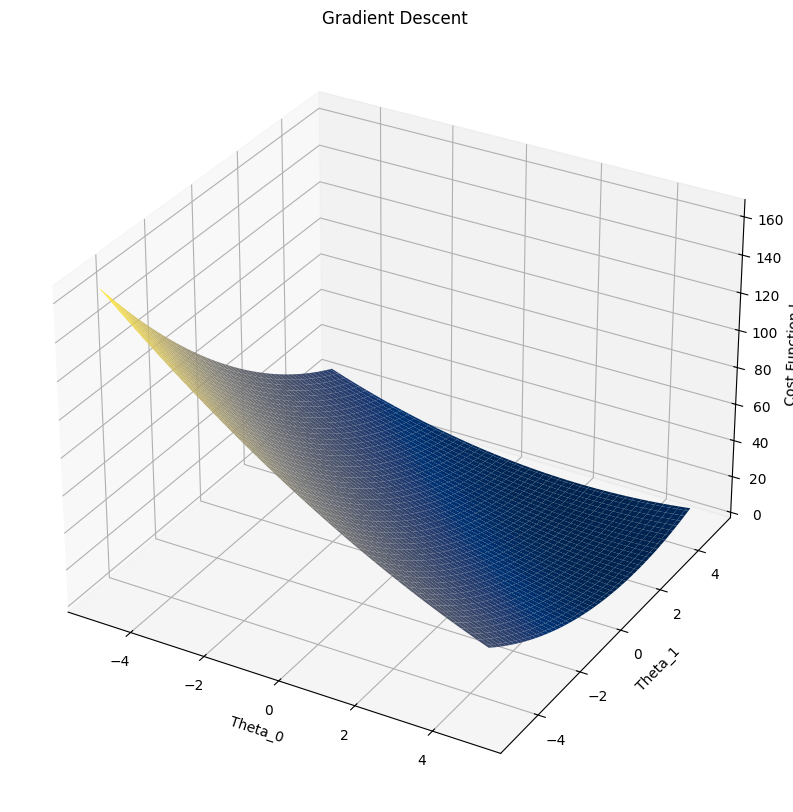

In [13]:
fig = plt.figure(figsize=(12, 10))
ax = fig.add_subplot(projection='3d')
ax.plot_surface(theta_0_grid, theta_1_grid, cost_grid, cmap = 'cividis')

ax.set_xlabel('Theta_0')
ax.set_ylabel('Theta_1')
ax.set_zlabel('Cost Function J')
ax.set_title('Gradient Descent')

plt.show()

Finally putting it all together and fitting the line. We not plot the points from the training set and plot the line made with $\theta_{0}$ and $\theta_{1}$

In [15]:
x_plot = np.linspace(0,2,50)
y_plot = theta_0 + x_plot * theta_1

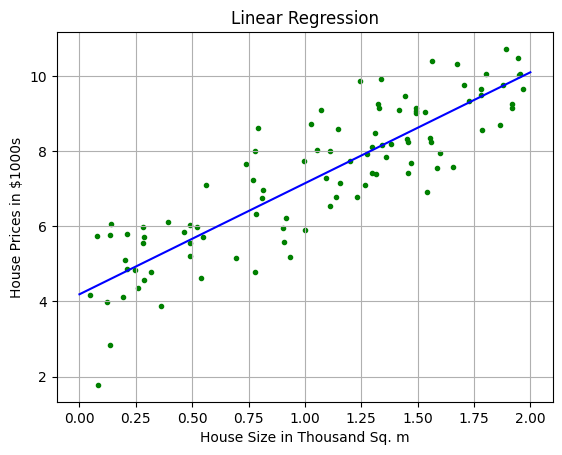

In [18]:
plt.scatter(x_train,y_train, c='g', marker = '.')
plt.title('Linear Regression')
plt.xlabel('House Size in Thousand Sq. m')
plt.ylabel('House Prices in $1000s')
plt.grid(True)
plt.plot(x_plot, y_plot, c= 'b')
plt.show()